# Plot de Espectros UV-Vis

Notebook genérico para ler arquivos de absorbância vs comprimento de onda.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
def ler_espectro(caminho_arquivo):
    wavelengths = []
    absorbancias = []

    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        linhas = f.readlines()

    for linha in linhas:
        linha = linha.strip()

        if not linha or 'Wavelength' in linha or 'Abs' in linha:
            continue

        partes = linha.split()

        if len(partes) >= 1:
            try:
                wl = float(partes[0])

                # Pode ter linha sem absorbância
                if len(partes) > 1:
                    abs_val = float(partes[1])
                else:
                    continue

                wavelengths.append(wl)
                absorbancias.append(abs_val)

            except ValueError:
                continue

    df = pd.DataFrame({
        'Wavelength (nm)': wavelengths,
        'Absorbance': absorbancias
    })

    return df

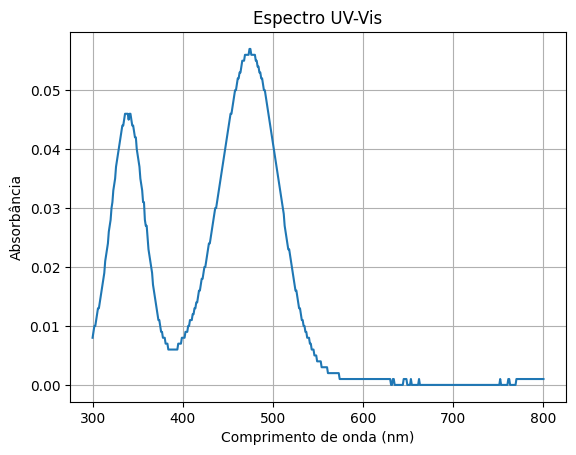

In [ ]:
arquivo = 'CoNH36_1mM_HPF.txt'

df = ler_espectro(arquivo)

plt.figure()
plt.plot(df['Wavelength (nm)'], df['Absorbance'])
plt.xlabel('Comprimento de onda (nm)')
plt.ylabel('Absorbância')
plt.title('Espectro UV-Vis')
plt.grid()
plt.show()

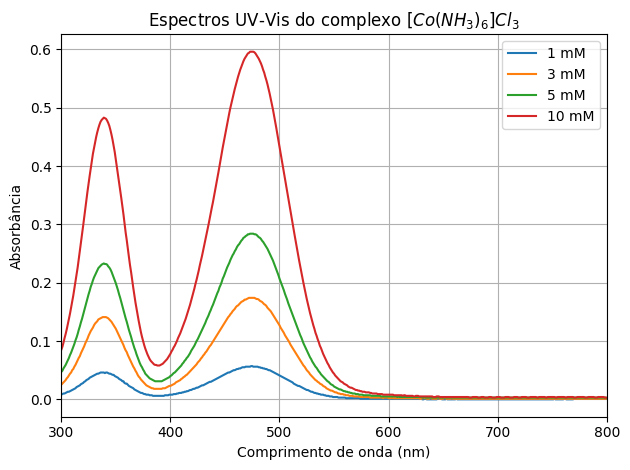

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

pasta = '.'

legendas = {
    'CoNH36_1mM_HPF.txt': '1 mM',
    'CoNH36_3mM_HPF.txt': '3 mM',
    'CoNH36_5mM_HPF.txt': '5 mM',
    'CoNH36_10mM_HPF.txt': '10 mM'
}

def ler_espectro(caminho):
    df = pd.read_csv(
        caminho,
        skiprows=1,
        sep='\t',
        quotechar='"'
    )
    df.columns = ['Wavelength (nm)', 'Absorbance']
    return df

def extrair_concentracao(nome_arquivo):
    match = re.search(r'_(\d+)mM', nome_arquivo)
    if match:
        return int(match.group(1))
    return 0

plt.figure()

arquivos_txt = sorted(
    [a for a in os.listdir(pasta) if a.endswith('_HPF.txt')],
    key=extrair_concentracao
)

for arquivo in arquivos_txt:
    caminho = os.path.join(pasta, arquivo)

    try:
        df = ler_espectro(caminho)

        plt.plot(
            df['Wavelength (nm)'],
            df['Absorbance'],
            label=legendas.get(arquivo, arquivo.replace('_HPF.txt',''))
        )

    except Exception as e:
        print(f'Erro ao ler {arquivo}: {e}')

plt.xlabel('Comprimento de onda (nm)')
plt.xlim(300, 800)
plt.ylabel('Absorbância')
plt.title('Espectros UV-Vis do complexo $[Co(NH_3)_6]Cl_3$')
plt.legend()
plt.grid()
plt.tight_layout()
#plt.savefig('espectros_uv_vis2.png', dpi=300)
plt.show()

               Arquivo  λmax (nm)  Absmax  Concentração     ε
0   CoNH36_1mM_HPF.txt      474.0   0.057         0.001  57.0
1   CoNH36_3mM_HPF.txt      472.0   0.174         0.003  58.0
2   CoNH36_5mM_HPF.txt      473.0   0.284         0.005  56.8
3  CoNH36_10mM_HPF.txt      473.0   0.596         0.010  59.6

ε (pela regressão) = 60 L/mol·cm
R² = 0.9993


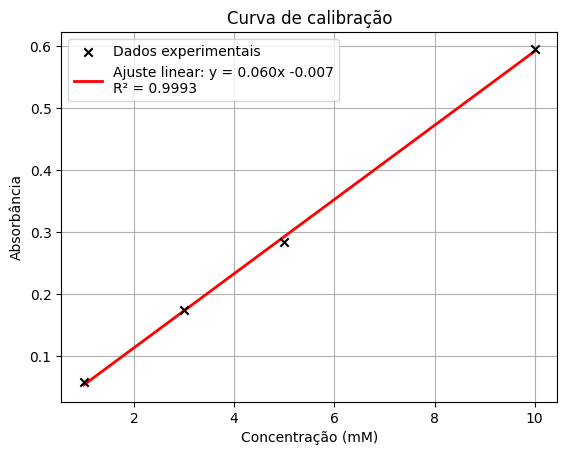

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def ler_espectro(caminho):
    wl = []
    abs_ = []

    with open(caminho, 'r', encoding='utf-8') as f:
        for linha in f:
            linha = linha.strip()

            if not linha or 'Wavelength' in linha:
                continue

            partes = linha.split()

            if len(partes) >= 2:
                try:
                    wl.append(float(partes[0]))
                    abs_.append(float(partes[1]))
                except:
                    pass

    return pd.DataFrame({'wl': wl, 'abs': abs_})


def encontrar_max(df):
    idx = df['abs'].idxmax()
    return df.loc[idx, 'wl'], df.loc[idx, 'abs']


arquivos = [
    "CoNH36_1mM_HPF.txt",
    "CoNH36_3mM_HPF.txt",
    "CoNH36_5mM_HPF.txt",
    "CoNH36_10mM_HPF.txt"
]

concentracoes = [
    1.0e-3,
    3.0e-3,
    5.0e-3,
    1.0e-2
]

b = 1  # cm

resultados = []

for arq, c in zip(arquivos, concentracoes):
    df = ler_espectro(arq)
    lam_max, abs_max = encontrar_max(df)

    epsilon = abs_max / (b * c)

    resultados.append([arq, lam_max, abs_max, c, epsilon])

tabela = pd.DataFrame(resultados, columns=[
    'Arquivo', 'λmax (nm)', 'Absmax', 'Concentração', 'ε'
])

print(tabela)


abs_list = tabela['Absmax']
conc_list = tabela['Concentração']

slope, intercept, r, p, std_err = linregress(conc_list, abs_list)

print(f"\nε (pela regressão) = {slope:.0f} L/mol·cm")
print(f"R² = {r**2:.4f}")


plt.figure()

conc_mM = conc_list * 1000

plt.grid(True, zorder=0)

plt.scatter(
    conc_mM,
    abs_list,
    color='black',
    marker='x',
    #s=80,
    zorder=3,
    label='Dados experimentais'
)

x = np.linspace(min(conc_list), max(conc_list), 100)
y = slope * x + intercept

slope_mM = slope / 1000

plt.plot(
    x * 1000,
    y,
    color='red',
    linewidth=2,
    zorder=2,
    label=f'Ajuste linear: y = {slope_mM:.3f}x {intercept:.3f}\nR² = {r**2:.4f}'
)

plt.xlabel('Concentração (mM)')
plt.ylabel('Absorbância')
plt.title('Curva de calibração')

plt.legend()
#plt.savefig('curva_calibracao.png', dpi=300)
plt.show()

C:\Users\jvito\AppData\Local\Temp\ipykernel_19008\3369005532.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


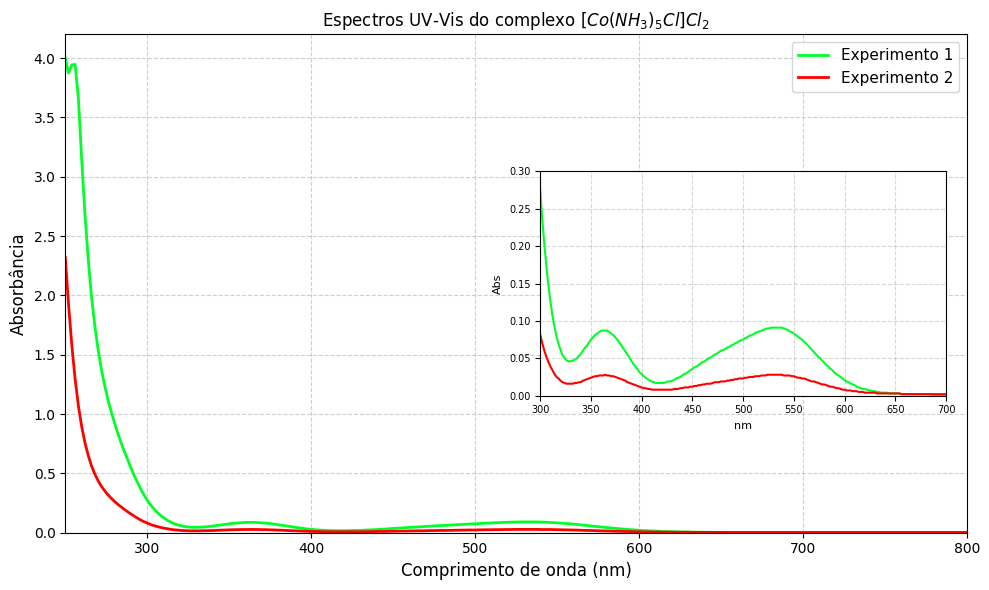

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

df1 = pd.read_csv("co_nh35cl_cl2_jv_fl.txt", skiprows=2, sep='\t', names=['Wavelength', 'Abs'])
df2 = pd.read_csv("co_nh35cl_cl2_jv_fl_v2.txt", skiprows=2, sep='\t', names=['Wavelength', 'Abs'])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df1['Wavelength'], df1['Abs'], color="#00ff2a", linewidth=2, label='Experimento 1')
ax.plot(df2['Wavelength'], df2['Abs'], color="#ff0000", linewidth=2, label='Experimento 2')

ax.set_xlabel('Comprimento de onda (nm)', fontsize=12)
ax.set_ylabel('Absorbância', fontsize=12)
ax.set_title('Espectros UV-Vis do complexo $[Co(NH_3)_5Cl]Cl_2$')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.6)

ax.set_xlim(250, 800)
ax.set_ylim(bottom=0)  

# -------------------------------------------------
axins = inset_axes(ax, width="45%", height="45%", loc='center right', borderpad=1.5)


axins.plot(df1['Wavelength'], df1['Abs'], color="#00ff2a", linewidth=1.5)
axins.plot(df2['Wavelength'], df2['Abs'], color="#ff0000", linewidth=1.5)


axins.set_xlim(300, 700)
axins.set_ylim(0, 0.3)

axins.grid(True, linestyle='--', alpha=0.5)
axins.set_xlabel('nm', fontsize=8)
axins.set_ylabel('Abs', fontsize=8)
axins.tick_params(axis='both', labelsize=7)

plt.tight_layout()
#plt.savefig('espectros_com_inset.png', dpi=300)
plt.show()